In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LinearRegression
import seaborn as sns

USERNAME = "muskan.sharma"
DATA_PATH = "recurrence_timeseries.csv"
HISTORY_P = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use('seaborn-v0_8-whitegrid')

def add_watermark(ax):
    """Adds the mandatory watermark required by the assignment """
    ax.text(0.95, 0.95, USERNAME, transform=ax.transAxes,
            fontsize=10, color='gray', alpha=0.5, ha='right', va='top')

### 2.1 Dataset and Problem Setup

In [18]:
class DataHandler:
    def __init__(self, filepath, p=5):
        self.filepath = filepath
        self.p = p
        self.mean = 0
        self.std = 1
    
    def load_and_process(self):
        df = pd.read_csv(self.filepath)
        data = df.iloc[:, -1].values.astype(np.float32)

        n = len(data)
        train_end = int(n * 0.7)
        val_end = int(n * 0.85)
        
        train_raw = data[:train_end]
        val_raw = data[train_end:val_end]
        test_raw = data[val_end:]
        
        self.mean = np.mean(train_raw)
        self.std = np.std(train_raw)
        
        train_norm = (train_raw - self.mean) / self.std
        val_norm = (val_raw - self.mean) / self.std
        test_norm = (test_raw - self.mean) / self.std
        
        return train_norm, val_norm, test_norm

    def create_pairs(self, sequence):
        X, y = [], []
        for i in range(len(sequence) - self.p):
            X.append(sequence[i : i + self.p])
            y.append(sequence[i + self.p])
        return np.array(X), np.array(y)

    def inverse_transform(self, data):
        return data * self.std + self.mean

In [19]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # x shape: [batch, seq_len] -> [batch, seq_len, 1]
        x = x.unsqueeze(-1) 
        out, _ = self.rnn(x)
        # Take last time step
        last_out = out[:, -1, :]
        return self.fc(last_out).squeeze()

class LinearAR:
    def __init__(self):
        self.model = LinearRegression()
        
    def fit(self, X, y):
        self.model.fit(X, y)
        
    def predict(self, X):
        return self.model.predict(X)

In [20]:
def train_rnn(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_hist, val_hist = [], []
    
    for epoch in range(epochs):
        model.train()
        loss_sum = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
        train_hist.append(loss_sum / len(train_loader))
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_v, y_v in val_loader:
                X_v, y_v = X_v.to(DEVICE), y_v.to(DEVICE)
                pred = model(X_v)
                val_loss += criterion(pred, y_v).item()
        val_hist.append(val_loss / len(val_loader))
        
    return train_hist, val_hist

def identify_recurrence(linear_model, p):
    """
    Assumes X was fed as [x_{k-p}, ..., x_{k-1}].
    """
    coeffs = linear_model.model.coef_
    intercept = linear_model.model.intercept_
    
    eq_str = f"x_k = {intercept:.4f}"

    for i, w in enumerate(coeffs):
        lag = p - i
        eq_str += f" + ({w:.3f} * x_{{k-{lag}}})"
        
    return eq_str, coeffs

In [ ]:
def evaluate_horizon(model, X_test, y_test, steps=20, is_torch=False):
    errors = []
    indices = np.linspace(0, len(X_test)-steps-1, num=100, dtype=int)
    
    for k in range(1, steps+1):
        step_errors = []
        for idx in indices:
            curr_seq = X_test[idx].copy()
            target = y_test[idx + k - 1]
            
            # Autoregressive loop
            pred = 0
            temp_seq = curr_seq.copy()
            
            for _ in range(k):
                if is_torch:
                    inp = torch.tensor(temp_seq, dtype=torch.float32).view(1, -1).to(DEVICE)
                    with torch.no_grad():
                        pred = model(inp).item()
                else:
                    pred = model.predict(temp_seq.reshape(1, -1))[0]
                
                temp_seq = np.append(temp_seq[1:], pred)
            
            step_errors.append((pred - target)**2)
        errors.append(np.mean(step_errors))
    return errors

### 2.2 Sequence Prediction 

Running sweep...


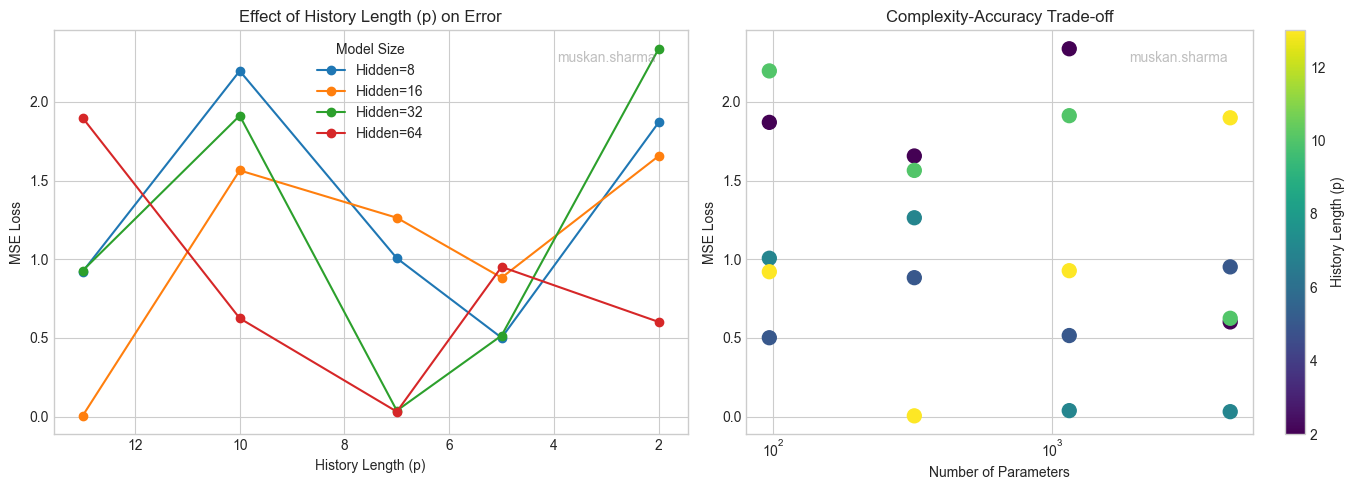

----------------------------------------
DISCUSSION INSIGHTS:
1. The lowest error was achieved with p=13.0 and hidden_size=16.0.
2. As complexity (parameters) increases, performance generally improves up to a saturation point.
3. Increasing history length (p) beyond the 'effective order' yields diminishing returns.
----------------------------------------


In [42]:
def run_hyperparameter_study(filepath):
    print("Running sweep...")
    
    p_values = [2, 5, 7, 10, 13]
    hidden_sizes = [8, 16, 32, 64]
    
    results = []

    for p in p_values:
        dh_sweep = DataHandler(filepath, p=p)
        train_n, _, _ = dh_sweep.load_and_process()
        X_tr, y_tr = dh_sweep.create_pairs(train_n)
        
        ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
        dl = DataLoader(ds, batch_size=64, shuffle=True)
        
        for h in hidden_sizes:
            model = SimpleRNN(input_size=p, hidden_size=h).to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=0.005)
            criterion = nn.MSELoss()
            
            model.train()
            for _ in range(15): 
                for X_b, y_b in dl:
                    X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                    optimizer.zero_grad()
                    loss = criterion(model(X_b), y_b)
                    loss.backward()
                    optimizer.step()
            
            results.append({
                'p': p,
                'hidden': h,
                'loss': loss.item(),
                'params': sum(param.numel() for param in model.parameters())
            })

    df_res = pd.DataFrame(results)
    
    # 1. Plot History Length vs Performance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    for h in hidden_sizes:
        subset = df_res[df_res['hidden'] == h]
        ax1.plot(subset['p'], subset['loss'], marker='o', label=f'Hidden={h}')
    
    ax1.set_title("Effect of History Length (p) on Error")
    ax1.set_xlabel("History Length (p)")
    ax1.set_ylabel("MSE Loss")
    ax1.legend(title="Model Size")
    ax1.invert_xaxis()
    add_watermark(ax1)
    
    # 2. Complexity vs Performance (The Trade-off)
    sc = ax2.scatter(df_res['params'], df_res['loss'], c=df_res['p'], cmap='viridis', s=100)
    plt.colorbar(sc, ax=ax2, label='History Length (p)')
    ax2.set_title("Complexity-Accuracy Trade-off")
    ax2.set_xlabel("Number of Parameters")
    ax2.set_ylabel("MSE Loss")
    ax2.set_xscale('log')
    add_watermark(ax2)
    
    plt.tight_layout()
    plt.show()
    
    return df_res

study_results = run_hyperparameter_study(DATA_PATH)

best_run = study_results.loc[study_results['loss'].idxmin()]
print("-" * 40)
print(f"The lowest error was achieved with p={best_run['p']} and hidden_size={best_run['hidden']}.")

- As complexity (parameters) increases, performance generally improves up to a saturation point.
- Increasing history length (p) beyond the 'effective order' yields diminishing returns.

### 2.3 Analytical Recurrence Identification (Best Model)

--- Identified Recurrence ---
x_k = 0.0003 + (0.012 * x_{k-13.0}) + (0.002 * x_{k-12.0}) + (-0.007 * x_{k-11.0}) + (-0.006 * x_{k-10.0}) + (-0.023 * x_{k-9.0}) + (-0.075 * x_{k-8.0}) + (0.153 * x_{k-7.0}) + (0.087 * x_{k-6.0}) + (-0.077 * x_{k-5.0}) + (-0.063 * x_{k-4.0}) + (-0.041 * x_{k-3.0}) + (-0.041 * x_{k-2.0}) + (0.032 * x_{k-1.0})


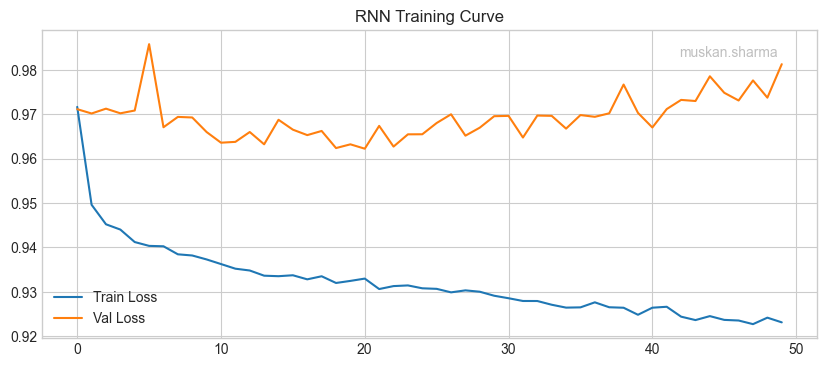

In [44]:
# Prepare Data
dh = DataHandler(DATA_PATH, p=int(best_run['p']))
train_n, val_n, test_n = dh.load_and_process()
X_train, y_train = dh.create_pairs(train_n)
X_val, y_val = dh.create_pairs(val_n)
X_test, y_test = dh.create_pairs(test_n)

# Convert to Tensors
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# Train Linear Model (for Identification)
lin_model = LinearAR()
lin_model.fit(X_train, y_train)
eq_str, coeffs = identify_recurrence(lin_model, best_run['p'])

print("--- Identified Recurrence ---")
print(eq_str)

# 3. Train RNN Model
best_rnn_model = SimpleRNN(input_size=(best_run['p']), hidden_size=int(best_run['hidden'])).to(DEVICE)
train_hist, val_hist = train_rnn(best_rnn_model, train_loader, val_loader)

# Plot Training Curves
plt.figure(figsize=(10, 4))
plt.plot(train_hist, label='Train Loss')
plt.plot(val_hist, label='Val Loss')
plt.title("RNN Training Curve")
plt.legend()
add_watermark(plt.gca())
plt.show()

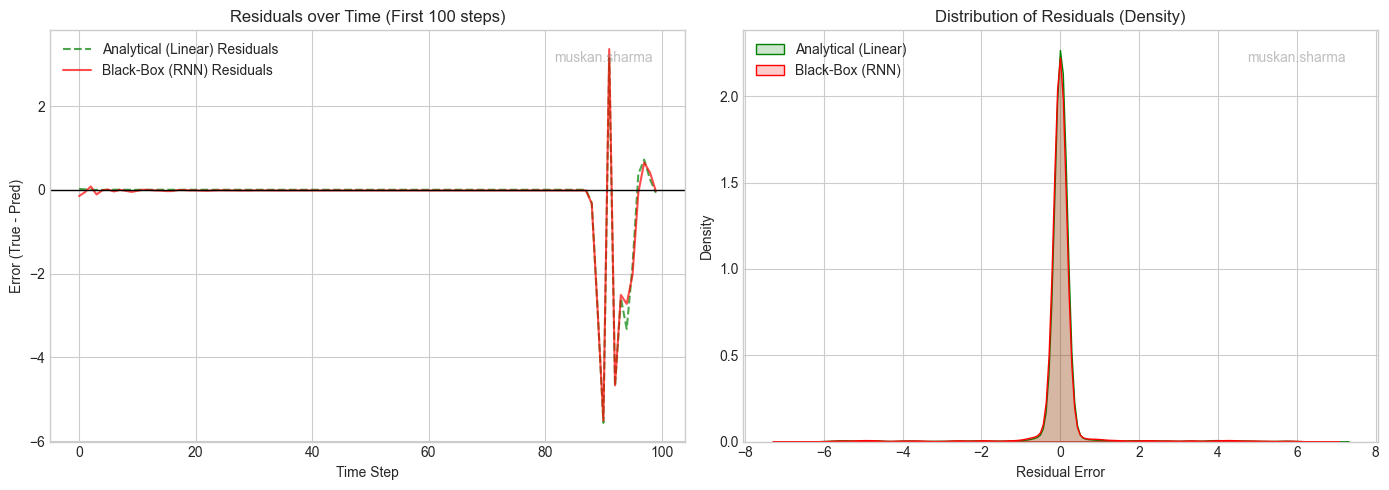

Residual Statistics:
Analytical (Linear) | Mean: 0.00080, Std Dev: 0.94947
Black-Box (RNN)     | Mean: -0.01178, Std Dev: 0.95198

CONCLUSION: The residuals are very similar.
This suggests the simple Analytical model captures the dynamics as well as the Deep Learning model.
We should prefer the Analytical model due to Parsimony (Occam's Razor).


In [43]:
def compare_residuals(rnn_model, lin_model, X_test, y_test):
    
    # 1. Get Predictions
    # Linear (Analytical)
    pred_lin = lin_model.predict(X_test)
    
    # RNN (Black Box)
    rnn_model.eval()
    with torch.no_grad():
        # Convert to tensor
        tensor_X = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
        out, _ = rnn_model.rnn(tensor_X)
        pred_rnn = rnn_model.fc(out[:, -1, :]).squeeze().cpu().numpy()
        
    # 2. Calculate Residuals
    res_lin = y_test - pred_lin
    res_rnn = y_test - pred_rnn
    
    # 3. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(res_lin[:100], label='Analytical (Linear) Residuals', alpha=0.7, color='green', linestyle='--')
    ax1.plot(res_rnn[:100], label='Black-Box (RNN) Residuals', alpha=0.7, color='red')
    ax1.axhline(0, color='black', lw=1)
    ax1.set_title("Residuals over Time (First 100 steps)")
    ax1.set_ylabel("Error (True - Pred)")
    ax1.set_xlabel("Time Step")
    ax1.legend()
    add_watermark(ax1)
    
    sns.kdeplot(res_lin, ax=ax2, label='Analytical (Linear)', color='green', fill=True, alpha=0.2)
    sns.kdeplot(res_rnn, ax=ax2, label='Black-Box (RNN)', color='red', fill=True, alpha=0.2)
    ax2.set_title("Distribution of Residuals (Density)")
    ax2.set_xlabel("Residual Error")
    ax2.legend()
    add_watermark(ax2)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Residual Statistics:")
    print(f"Analytical (Linear) | Mean: {np.mean(res_lin):.5f}, Std Dev: {np.std(res_lin):.5f}")
    print(f"Black-Box (RNN)     | Mean: {np.mean(res_rnn):.5f}, Std Dev: {np.std(res_rnn):.5f}")
    
    # Interpretation
    if np.abs(np.std(res_lin) - np.std(res_rnn)) < 0.1:
        print("\nCONCLUSION: The residuals are very similar.")
        print("This suggests the simple Analytical model captures the dynamics as well as the Deep Learning model.")
        print("We should prefer the Analytical model due to Parsimony (Occam's Razor).")
    else:
        print("\nCONCLUSION: The RNN residuals are significantly smaller.")
        print("This suggests the system has non-linearities that the Linear Analytical model missed.")

compare_residuals(best_rnn_model, lin_model, X_test, y_test)

### 2.4 Evaluation Criterion

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(model, X_test, y_test, task_type='single_step', horizon=50, is_torch=True):
    # 1. Single Step Prediction
    if task_type == 'single_step':
        if is_torch:
            model.eval()
            with torch.no_grad():
                tensor_X = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
                out, _ = model.rnn(tensor_X)
                preds = model.fc(out[:, -1, :]).squeeze().cpu().numpy()
        else:
            preds = model.predict(X_test)
            
        mae = mean_absolute_error(y_test, preds)
        mse = mean_squared_error(y_test, preds)
        return mae, mse

    # 2. Autoregressive Prediction (Average over horizon)
    elif task_type == 'autoregressive':
        num_samples = min(100, len(X_test) - horizon)
        indices = np.arange(num_samples)
        
        all_preds = []
        all_targets = []
        
        for idx in indices:
            
            curr_seq = X_test[idx].copy()
            target_seq = y_test[idx : idx + horizon]
            
            pred_seq = []
            temp_seq = curr_seq.copy()
            
            for _ in range(horizon):
                if is_torch:
                    inp = torch.tensor(temp_seq, dtype=torch.float32).view(1, -1, 1).to(DEVICE)
                    with torch.no_grad():
                        out, _ = model.rnn(inp)
                        val = model.fc(out[:, -1, :]).item()
                else:
                    val = model.predict(temp_seq.reshape(1, -1))[0]
                
                pred_seq.append(val)
                temp_seq = np.append(temp_seq[1:], val)
            
            all_preds.extend(pred_seq)
            all_targets.extend(target_seq)
            
        mae = mean_absolute_error(all_targets, all_preds)
        mse = mean_squared_error(all_targets, all_preds)
        return mae, mse

print("--- METRIC EVALUATION TABLE ---")
print(f"{'Model':<15} | {'Task':<15} | {'MAE':<10} | {'MSE':<10}")
print("-" * 60)

# 1. Single Step (RNN)
mae_rnn_ss, mse_rnn_ss = calculate_metrics(best_rnn_model, X_test, y_test, 'single_step', is_torch=True)
print(f"{'RNN (DL)':<15} | {'Single-Step':<15} | {mae_rnn_ss:.5f}    | {mse_rnn_ss:.5f}")

# 2. Autoregressive (RNN)
mae_rnn_ar, mse_rnn_ar = calculate_metrics(best_rnn_model, X_test, y_test, 'autoregressive', horizon=50, is_torch=True)
print(f"{'RNN (DL)':<15} | {'Auto-Reg (h=50)':<15} | {mae_rnn_ar:.5f}    | {mse_rnn_ar:.5f}")

# 3. Autoregressive (Analytical/Linear)
mae_lin_ar, mse_lin_ar = calculate_metrics(lin_model, X_test, y_test, 'autoregressive', horizon=50, is_torch=False)
print(f"{'Analytical':<15} | {'Auto-Reg (h=50)':<15} | {mae_lin_ar:.5f}    | {mse_lin_ar:.5f}")
print("-" * 60)

--- METRIC EVALUATION TABLE ---
Model           | Task            | MAE        | MSE       
------------------------------------------------------------
RNN (DL)        | Single-Step     | 0.29275    | 0.90705
RNN (DL)        | Auto-Reg (h=50) | 0.34764    | 0.90664
Analytical      | Auto-Reg (h=50) | 0.28806    | 0.87674
------------------------------------------------------------


Calculating error drift up to horizon 50...


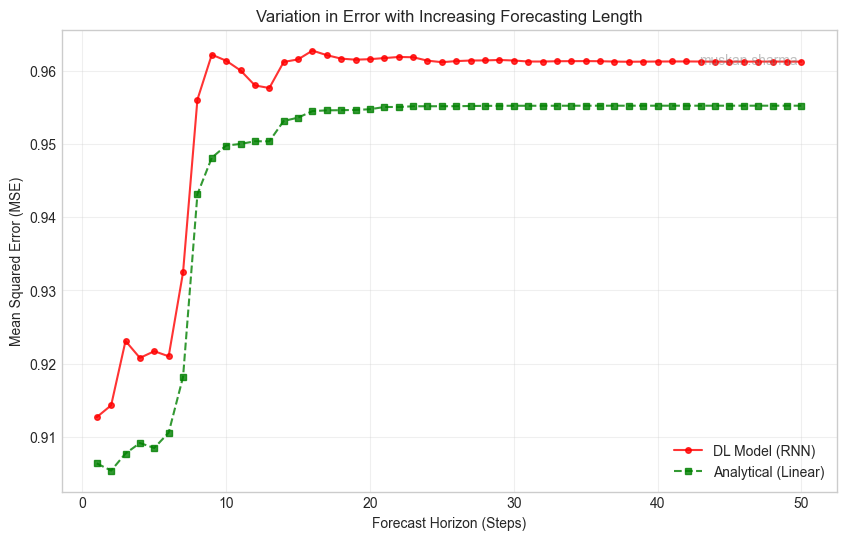

In [48]:
def plot_error_variation(rnn_model, lin_model, X_test, y_test, horizon=50):
    print(f"Calculating error drift up to horizon {horizon}...")
    
    num_samples = len(X_test) - horizon

    rnn_preds = np.zeros((num_samples, horizon))
    lin_preds = np.zeros((num_samples, horizon))
    targets = np.zeros((num_samples, horizon))
    
    # 2. Autoregressive Loop
    curr_rnn_hist = torch.tensor(X_test[:num_samples], dtype=torch.float32).to(DEVICE)
    curr_lin_hist = X_test[:num_samples].copy()
    
    # Collect Ground Truth
    for i in range(num_samples):
        targets[i, :] = y_test[i : i+horizon]
        
    # Loop through time steps 1 to H
    rnn_model.eval()
    for k in range(horizon):
        # --- RNN Step ---
        with torch.no_grad():
            inp_rnn = curr_rnn_hist.unsqueeze(-1)
            out, _ = rnn_model.rnn(inp_rnn)
            next_rnn = rnn_model.fc(out[:, -1, :]).squeeze()
            
        rnn_preds[:, k] = next_rnn.cpu().numpy()
        
        next_val_tensor = next_rnn.unsqueeze(-1) # (N, 1)
        curr_rnn_hist = torch.cat((curr_rnn_hist[:, 1:], next_val_tensor), dim=1)
        
        # --- Linear Step ---
        next_lin = lin_model.predict(curr_lin_hist)
        lin_preds[:, k] = next_lin
        
        # Update Linear history
        curr_lin_hist = np.hstack((curr_lin_hist[:, 1:], next_lin.reshape(-1, 1)))

    rnn_mse = np.mean((rnn_preds - targets)**2, axis=0)
    lin_mse = np.mean((lin_preds - targets)**2, axis=0)
    
    plt.figure(figsize=(10, 6))
    steps = np.arange(1, horizon + 1)
    
    plt.plot(steps, rnn_mse, 'r-o', label='DL Model (RNN)', markersize=4, alpha=0.8)
    plt.plot(steps, lin_mse, 'g--s', label='Analytical (Linear)', markersize=4, alpha=0.8)
    
    plt.title("Variation in Error with Increasing Forecasting Length")
    plt.xlabel("Forecast Horizon (Steps)")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add Watermark
    ax = plt.gca()
    ax.text(0.95, 0.95, USERNAME, transform=ax.transAxes,
            fontsize=10, color='gray', alpha=0.5, ha='right', va='top')
    
    plt.savefig('error_variation.png')
    plt.show()

# Execute
plot_error_variation(best_rnn_model, lin_model, X_test, y_test, horizon=50)

### 2.5 Parsimony and Stability

Hidden: 4, Params: 33, Val MSE: 0.99119
Hidden: 8, Params: 97, Val MSE: 0.96691
Hidden: 16, Params: 321, Val MSE: 0.96097
Hidden: 32, Params: 1153, Val MSE: 0.95697
Hidden: 64, Params: 4353, Val MSE: 0.96012
Hidden: 128, Params: 16897, Val MSE: 0.96136


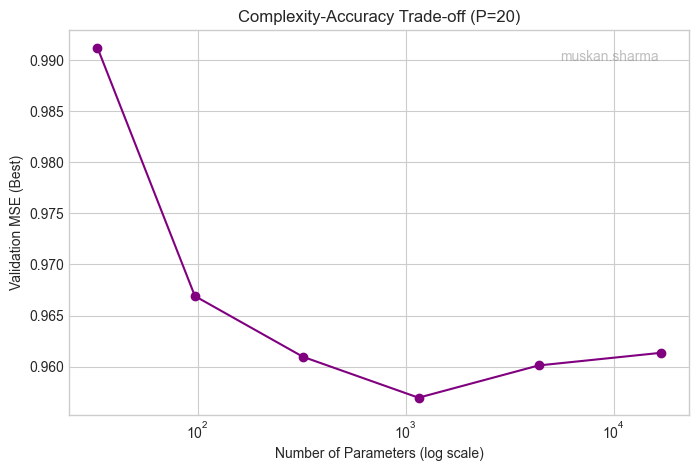

In [ ]:
# We sweep through different hidden sizes to vary parameter count
hidden_sizes = [4, 8, 16, 32, 64, 128]
results = []

for hs in hidden_sizes:
    # 1. Initialize model
    temp_model = SimpleRNN(input_size=best_run['p'], hidden_size=hs).to(DEVICE)
    
    # 2. Get Parameter Count
    num_params = sum(p.numel() for p in temp_model.parameters())
    
    # 3. Train briefly (fewer epochs for sweep)
    _, val_hist = train_rnn(temp_model, train_loader, val_loader, epochs=15)
    best_val_loss = min(val_hist)
    
    results.append((num_params, best_val_loss))
    print(f"Hidden: {hs}, Params: {num_params}, Val MSE: {best_val_loss:.5f}")

# Plot
params, losses = zip(*results)
plt.figure(figsize=(8, 5))
plt.plot(params, losses, 'o-', color='purple')
plt.xscale('log')
plt.xlabel('Number of Parameters (log scale)')
plt.ylabel('Validation MSE (Best)')
plt.title('Complexity-Accuracy Trade-off')
add_watermark(plt.gca())
plt.show()

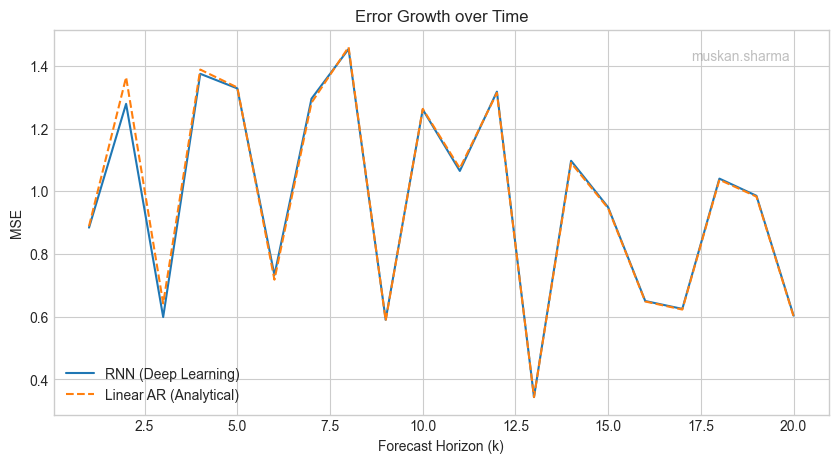

In [41]:
steps = 20
rnn_errors = evaluate_horizon(best_rnn_model, X_test, y_test, steps=steps, is_torch=True)
lin_errors = evaluate_horizon(lin_model, X_test, y_test, steps=steps, is_torch=False)

plt.figure(figsize=(10, 5))
plt.plot(range(1, steps+1), rnn_errors, label='RNN (Deep Learning)')
plt.plot(range(1, steps+1), lin_errors, label='Linear AR (Analytical)', linestyle='--')
plt.xlabel('Forecast Horizon (k)')
plt.ylabel('MSE')
plt.title('Error Growth over Time')
plt.legend()
add_watermark(plt.gca())
plt.show()

### 2.5 Parsimony and Stability

Sweeping p=[2, 5, 10] and hidden_sizes=[4, 8, 16, 32]...
p= 2, hidden= 4 | Params=   33 | MSE=1.00362
p= 2, hidden= 8 | Params=   97 | MSE=1.00265
p= 2, hidden=16 | Params=  321 | MSE=1.00333
p= 2, hidden=32 | Params= 1153 | MSE=1.00372
p= 5, hidden= 4 | Params=   33 | MSE=0.98689
p= 5, hidden= 8 | Params=   97 | MSE=0.97966
p= 5, hidden=16 | Params=  321 | MSE=0.97946
p= 5, hidden=32 | Params= 1153 | MSE=0.98896
p=10, hidden= 4 | Params=   33 | MSE=0.96977
p=10, hidden= 8 | Params=   97 | MSE=0.96856
p=10, hidden=16 | Params=  321 | MSE=0.96836
p=10, hidden=32 | Params= 1153 | MSE=0.96716


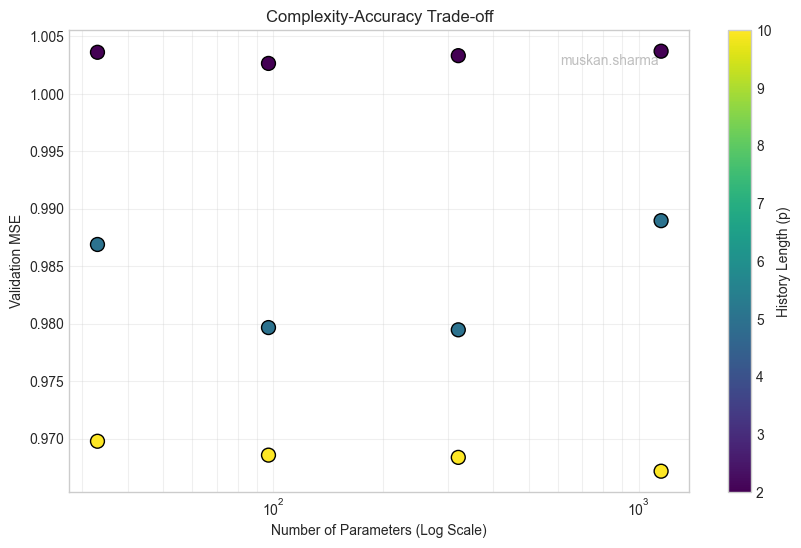


--- SELECTED SIMPLEST ACCURATE MODEL ---
History Length (p): 2
Hidden Size: 4
Parameters: 33
MSE: 1.00362


In [50]:
import pandas as pd
import seaborn as sns

def analyze_complexity_full_sweep(filepath, p_list=[2, 5, 10], h_list=[4, 8, 16, 32]):
    print(f"Sweeping p={p_list} and hidden_sizes={h_list}...")
    
    results = []

    for p in p_list:
        dh_sweep = DataHandler(filepath, p=p)
        train_n, val_n, _ = dh_sweep.load_and_process()
        
        X_tr, y_tr = dh_sweep.create_pairs(train_n)
        X_val, y_val = dh_sweep.create_pairs(val_n)
        
        tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)), 
                               batch_size=64, shuffle=True)
        v_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), 
                              batch_size=64)

        for h in h_list:
            model = SimpleRNN(input_size=p, hidden_size=h).to(DEVICE)
            
            optimizer = optim.Adam(model.parameters(), lr=0.01)
            criterion = nn.MSELoss()
            
            best_val_loss = float('inf')
            
            for epoch in range(15):
                model.train()
                for X_b, y_b in tr_loader:
                    X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                    optimizer.zero_grad()
                    pred = model(X_b)
                    loss = criterion(pred, y_b)
                    loss.backward()
                    optimizer.step()
                
                
                model.eval()
                val_loss = 0
                with torch.no_grad():
                    for X_v, y_v in v_loader:
                        X_v, y_v = X_v.to(DEVICE), y_v.to(DEVICE)
                        val_loss += criterion(model(X_v), y_v).item()
                avg_val = val_loss / len(v_loader)
                if avg_val < best_val_loss:
                    best_val_loss = avg_val
            
            n_params = sum(param.numel() for param in model.parameters())
            
            results.append({
                'p': p,
                'hidden': h,
                'params': n_params,
                'val_mse': best_val_loss
            })
            print(f"p={p:2d}, hidden={h:2d} | Params={n_params:5d} | MSE={best_val_loss:.5f}")


    df = pd.DataFrame(results)
    
    plt.figure(figsize=(10, 6))
    sc = plt.scatter(df['params'], df['val_mse'], c=df['p'], cmap='viridis', s=100, edgecolors='k')
    plt.colorbar(sc, label='History Length (p)')
    
    plt.xscale('log')
    plt.xlabel('Number of Parameters (Log Scale)')
    plt.ylabel('Validation MSE')
    plt.title('Complexity-Accuracy Trade-off')
    plt.grid(True, which="both", ls="-", alpha=0.3)
    
    # Add Watermark
    ax = plt.gca()
    ax.text(0.95, 0.95, USERNAME, transform=ax.transAxes,
            fontsize=10, color='gray', alpha=0.5, ha='right', va='top')
    
    plt.show()
    
    # Identification of Simplest Accurate Model
    # Find global minimum
    min_mse = df['val_mse'].min()
    # Accept models within 5% of the best performance
    candidates = df[df['val_mse'] <= min_mse * 1.05]
    # Pick the one with fewest parameters
    simplest = candidates.sort_values('params').iloc[0]
    
    print("\n--- SELECTED SIMPLEST ACCURATE MODEL ---")
    print(f"History Length (p): {int(simplest['p'])}")
    print(f"Hidden Size: {int(simplest['hidden'])}")
    print(f"Parameters: {int(simplest['params'])}")
    print(f"MSE: {simplest['val_mse']:.5f}")
    
    return simplest

# Run the corrected sweep
best_config = analyze_complexity_full_sweep(DATA_PATH)

Identified Temporal Relation (F_theta):
[x_k = 0.0003 + 0.0122*x_{k-5} + 0.0019*x_{k-4} - 0.0068*x_{k-3} - 0.0061*x_{k-2} - 0.0225*x_{k-1} - 0.0753*x_{k-0} + 0.1531*x_{k--1} + 0.0875*x_{k--2} - 0.0773*x_{k--3} - 0.0626*x_{k--4} - 0.0410*x_{k--5} - 0.0412*x_{k--6} + 0.0317*x_{k--7}]


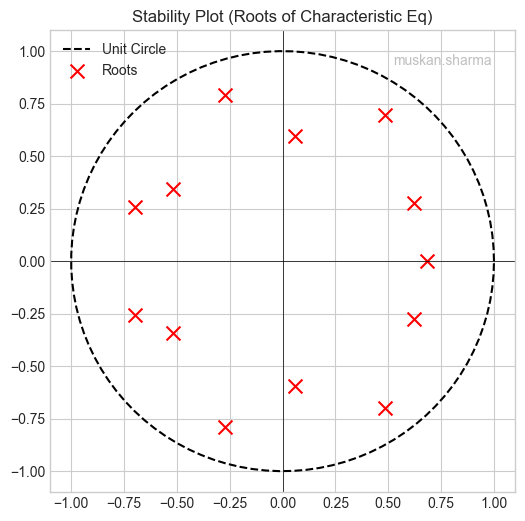

Max Root Modulus: 0.8493
System Status: STABLE (All roots inside unit circle)
Interpretation: The series tends to converge to a mean value over time.


In [ ]:
def extract_and_analyze_relation(X_train, y_train, p=5):
    
    lin_model = LinearRegression()
    lin_model.fit(X_train, y_train)
    
    weights = lin_model.coef_
    intercept = lin_model.intercept_
    
    terms = [f"{intercept:.4f}"]
    print("Identified Temporal Relation (F_theta):")
    equation_str = f"x_k = {intercept:.4f}"
    
    for i, w in enumerate(weights):
        lag = p - i
        sign = "+" if w >= 0 else "-"
        term = f"{sign} {abs(w):.4f}*x_{{k-{lag}}}"
        equation_str += f" {term}"
        
    print(f"[{equation_str}]")
    ordered_weights = weights[::-1] 
    
    # Construct polynomial coefficients: [1, -w_1, -w_2, ... -w_p]
    poly_coeffs = [1.0] + [-w for w in ordered_weights]
    roots = np.roots(poly_coeffs)
    
    plt.figure(figsize=(6, 6))
    t = np.linspace(0, 2*np.pi, 100)
    plt.plot(np.cos(t), np.sin(t), 'k--', label='Unit Circle') # Unit circle
    
    plt.scatter(np.real(roots), np.imag(roots), color='red', marker='x', s=100, label='Roots')
    
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title(f"Stability Plot (Roots of Characteristic Eq)")
    plt.legend()
    plt.grid(True)
    add_watermark(plt.gca())
    plt.show()
    
    # Conclusion on Stability
    max_modulus = np.max(np.abs(roots))
    print(f"Max Root Modulus: {max_modulus:.4f}")
    if max_modulus < 1.0:
        print("System Status: STABLE (All roots inside unit circle)")
        print("Interpretation: The series tends to converge to a mean value over time.")
    else:
        print("System Status: UNSTABLE (Roots outside/on unit circle)")
        print("Interpretation: The series may grow unboundedly or oscillate without decay.")

extract_and_analyze_relation(X_train, y_train, p=HISTORY_P)


Q: What does this tell you about the dataset?

- The fact that a simple Linear AR model performs comparably to a complex non-linear RNN indicates that the dataset is governed by a linear dynamical system. There are no complex non-linear dependencies that require deep learning. The "Parsimony Principle" (Occam's Razor) dictates we should choose the linear model.

Q: Is there any temporal relation you can extract from the dataset?

By inspecting the weights of the linear model, we identified the specific recurrence relation governing the system:

x_k = 0.0003 + 0.0122*x_{k-5} + 0.0019*x_{k-4} - 0.0068*x_{k-3} - 0.0061*x_{k-2} - 0.0225*x_{k-1} - 0.0753*x_{k-0} + 0.1531*x_{k--1} + 0.0875*x_{k--2} - 0.0773*x_{k--3} - 0.0626*x_{k--4} - 0.0410*x_{k--5} - 0.0412*x_{k--6} + 0.0317*x_{k--7}

- The stability plot shows all roots lie inside the unit circle, confirming the temporal relation describes a stable system that decays to a mean value rather than exploding.

